In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
df =  pd.read_csv(r"C:\Users\juned\Videos\data analytics\end to end projects\crypto-market-analytics-dashboard\data\clean_crypto_data.csv")

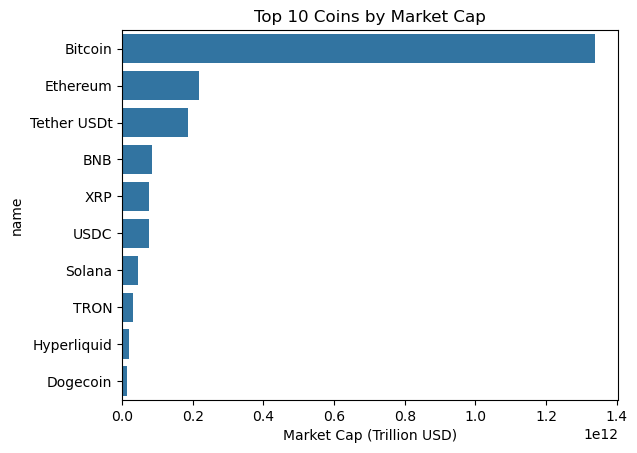

In [7]:
top10 = df[df['rank'] <= 10]
sns.barplot(data=top10, x = 'market_cap', y = 'name') 
plt.title('Top 10 Coins by Market Cap')
plt.xlabel('Market Cap (Trillion USD)')
plt.show()

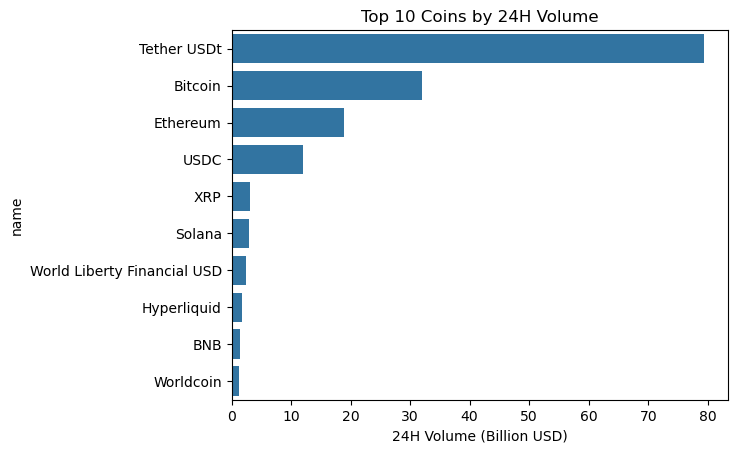

In [8]:
top10volume = df.sort_values('volume_24h', ascending=False).head(10)
top10volume['volume_b'] = top10volume['volume_24h'] / 1_000_000_000

sns.barplot(data=top10volume,x='volume_b',y='name')

plt.title('Top 10 Coins by 24H Volume')
plt.xlabel('24H Volume (Billion USD)')
plt.show()

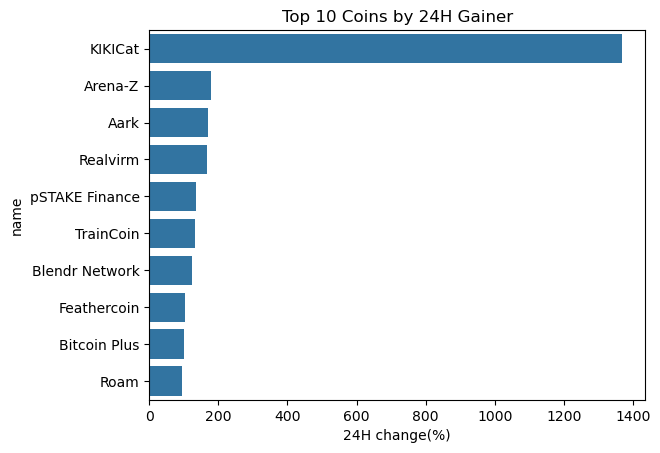

In [9]:
top10gainer = df.sort_values('change_24h', ascending=False).head(10)
sns.barplot(data=top10gainer, x = 'change_24h',y = 'name')

    
plt.title('Top 10 Coins by 24H Gainer')
plt.xlabel('24H change(%)')
plt.show()

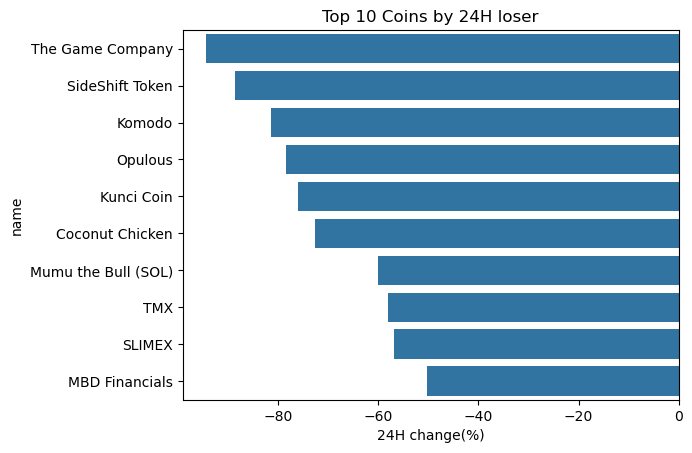

In [6]:
top10loser = df.sort_values('change_24h', ascending=True).head(10)
sns.barplot(data=top10loser, x = 'change_24h',y = 'name')

    
plt.title('Top 10 Coins by 24H loser')
plt.xlabel('24H change(%)')
plt.show()

In [7]:
volatility = (abs(df['change_1h']) + abs(df['change_24h'])+abs(df['change_7d'])+abs(df['change_30d']))
df.loc[volatility <= 10, 'Risk'] = 'Low_risk'
df.loc[(volatility > 10) & (volatility <= 20), 'Risk'] = 'Medium_risk'
df.loc[volatility > 20, 'Risk'] = 'High_risk'

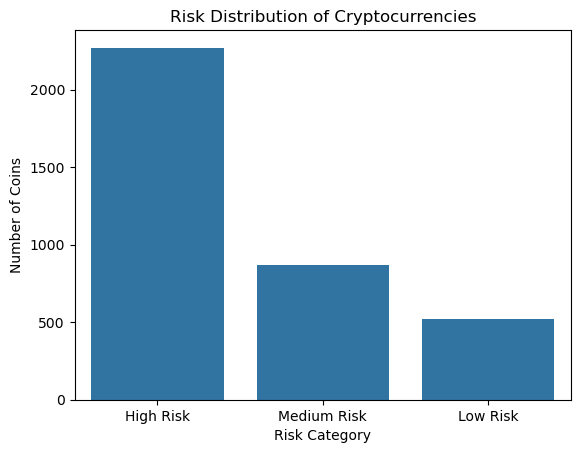

In [10]:
risk = df['Risk'].value_counts()

sns.barplot(
    x=risk.index,
    y=risk.values
)

plt.title('Risk Distribution of Cryptocurrencies')
plt.xlabel('Risk Category')
plt.ylabel('Number of Coins')

plt.show()

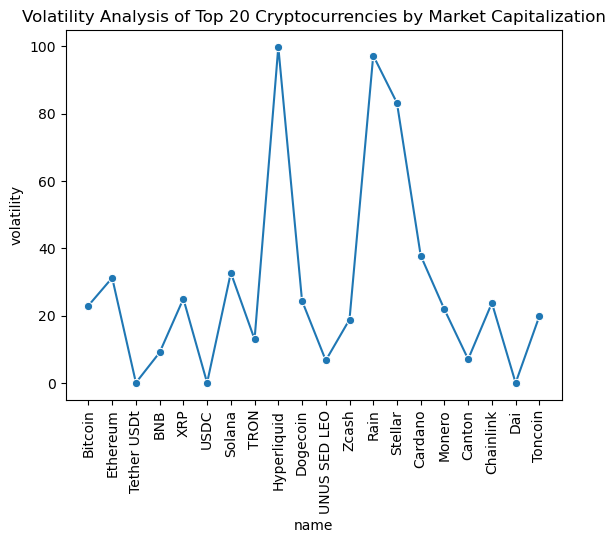

In [12]:
top20 = df.sort_values('market_cap',ascending = False).head(20)
df['volatility'] = (abs(df['change_1h']) + abs(df['change_24h'])+abs(df['change_7d'])+abs(df['change_30d']))
sns.lineplot(data=top20, x='name', y = 'volatility', marker ='o')
plt.xticks(rotation = 90)
plt.title('Volatility Analysis of Top 20 Cryptocurrencies by Market Capitalization')
plt.show()

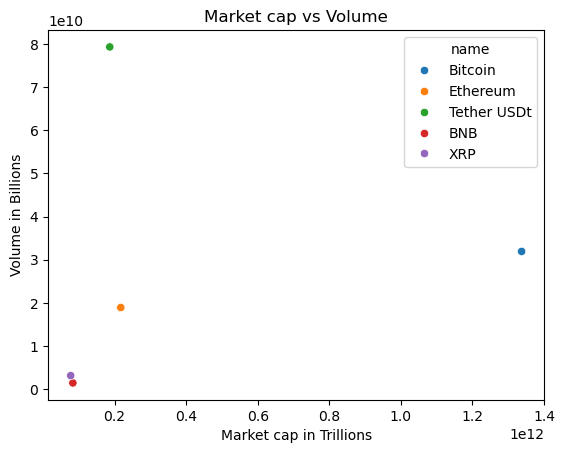

In [71]:
top25 = df[(df['rank'] > 0) & (df['rank'] <= 5)]
sns.scatterplot(data=top25, x = 'market_cap', y = 'volume_24h', hue = 'name')
plt.xlabel('Market cap in Trillions')
plt.ylabel('Volume in Billions')
plt.title('Market cap vs Volume')
plt.show()